In [ ]:
import os

repo_url = 'https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning.git'
repo_name = 'Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning'

# Clone the repository if it doesn't already exist
if not os.path.exists(repo_name):
    print(f"Cloning {repo_url}...")
    !git clone {repo_url}
    print("Repository cloned.")
else:
    print(f"Repository '{repo_name}' already exists.")

# Change directory to the cloned repository
# This changes the current working directory for this cell and subsequent cells.
%cd /content/{repo_name}

# Completely purge existing torch/numpy and hidden cache files
print("Uninstalling existing Python packages...")
!pip uninstall -y torch torchvision torchaudio numpy
!rm -rf /usr/local/lib/python3.12/dist-packages/~*

# Perform a fresh installation of compatible versions
print("Installing compatible versions of required packages...")
!pip install "numpy<2.0" "torch>=2.4.0" "transformers>=4.44.0" "transformer_lens" --quiet

print("\nEnvironment setup complete. You MUST now go to Runtime -> Restart session for changes to take effect and proceed with the notebook execution.")

### Action Required: Restart Runtime

Please go to `Runtime` -> `Restart session` in the Colab menu.

After restarting, please re-run the cells from the beginning to ensure all necessary modules are correctly imported and the `sys.path` is properly configured.

# Notebook 01: Baseline Replication

**Goal:** Replicate the induction circuit in the pretrained `attn-only-2l` model.

**Outputs:** `experiments/results/baseline_induction_scores.npz`, `paper/figures/fig3_*`

**Runtime:** ~5 minutes on CPU.

In [1]:
import sys
import os
from pathlib import Path

# Set absolute path to repo root
repo_root = "/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print("Modules imported successfully from src.")

Device: cuda
Modules imported successfully from src.


In [2]:
model_config = ModelConfig()
eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)
print(f'Loaded: {model_config.source} | {model.cfg.n_layers}L {model.cfg.n_heads}H')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

./model_final.pth:   0%|          | 0.00/210M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda
Loaded: attn-only-2l | 2L 8H


In [3]:
means, stds = compute_induction_score_with_stats(
    model=model, sequence_length=eval_config.induction_seq_length,
    num_sequences=eval_config.induction_num_sequences, seed=eval_config.seed, device=device,
)
heads = identify_induction_heads(means, threshold=0.5)
print('Induction heads (>=0.5):', heads)
for l in range(model.cfg.n_layers):
    for h in range(model.cfg.n_heads):
        print(f'  L{l}H{h}: {means[l,h]:.3f} +/- {stds[l,h]:.3f}')

Induction heads (>=0.5): []
  L0H0: 0.003 +/- 0.001
  L0H1: 0.013 +/- 0.002
  L0H2: 0.026 +/- 0.003
  L0H3: 0.004 +/- 0.001
  L0H4: 0.017 +/- 0.001
  L0H5: 0.014 +/- 0.004
  L0H6: 0.014 +/- 0.004
  L0H7: 0.281 +/- 0.029
  L1H0: 0.023 +/- 0.005
  L1H1: 0.018 +/- 0.003
  L1H2: 0.018 +/- 0.003
  L1H3: 0.015 +/- 0.005
  L1H4: 0.019 +/- 0.003
  L1H5: 0.017 +/- 0.006
  L1H6: 0.035 +/- 0.007
  L1H7: 0.021 +/- 0.003


In [4]:
results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
np.savez(results_dir / 'baseline_induction_scores.npz',
         means=means.cpu().numpy(), stds=stds.cpu().numpy(),
         induction_heads=np.array(heads))
print('Saved.')

Saved.


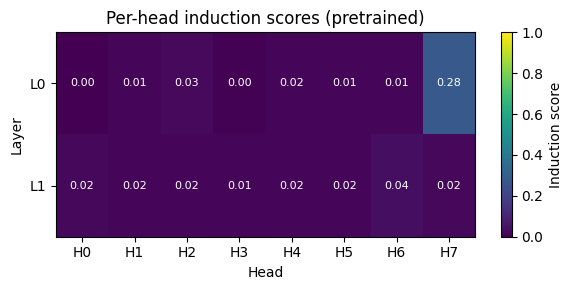

Figure 3 saved to: /content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/paper/figures/fig3_induction_scores_baseline.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
from pathlib import Path

# Ensure the directory exists using absolute path
figures_dir = Path('/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/paper/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

save_path = figures_dir / 'fig3_induction_scores_baseline.png'

# Generate and save the plot
fig = plot_induction_score_heatmap(
    means.cpu().numpy(),
    title='Per-head induction scores (pretrained)',
    save_path=str(save_path)
)
plt.show()

print(f'Figure 3 saved to: {save_path}')

# Trigger the download
if save_path.exists():
    print("Downloading image...")
    files.download(str(save_path))
else:
    print("Error: Figure file was not created.")